<h1 style="text-align:center; color:#0B5ED7; background:#E7F1FF; padding:18px; border-radius:12px;">
Predictive Analytics Project
</h1>

<h2 style="text-align:center; color:#198754;">
Air Passenger Traffic Forecasting Using Machine Learning
</h2>



<h2 style="color:#6F42C1;">1. Introduction</h2>

<p>
This project focuses on forecasting monthly air passenger traffic using historical
government data. Predictive analytics and machine learning models are applied to
identify trends, seasonality, and future passenger demand.
</p>


<h2 style="color:#6F42C1;">2. Dataset Description</h2>

<ul>
<li><b>Dataset:</b> Air Traffic Passenger Statistics</li>
<li><b>Source:</b> City of San Francisco Government (via Data.gov)</li>
<li><b>Type:</b> Secondary Government Dataset</li>
<li><b>Target Variable:</b> Passenger Count</li>
<li><b>Frequency:</b> Monthly</li>
</ul>


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score


In [4]:
df = pd.read_csv("C:\\Users\\singh\\Downloads\\Air_Traffic_Passenger_Statistics.csv")

df = df[['Activity Period', 'Passenger Count']]
df['Activity Period'] = pd.to_datetime(df['Activity Period'], format='%Y%m')

monthly_df = df.groupby('Activity Period')['Passenger Count'].sum().reset_index()
monthly_df = monthly_df.sort_values('Activity Period')

monthly_df['Time_Index'] = np.arange(len(monthly_df))
monthly_df['Month'] = monthly_df['Activity Period'].dt.month
monthly_df['Lag_1'] = monthly_df['Passenger Count'].shift(1)
monthly_df['Lag_3'] = monthly_df['Passenger Count'].shift(3)

monthly_df.dropna(inplace=True)
monthly_df.head()


,Activity Period,Passenger Count,Time_Index,Month,Lag_1,Lag_3
3,1999-10-01,3468846,3,10,3341964.0,3976746.0
4,1999-11-01,3145240,4,11,3468846.0,3972694.0
5,1999-12-01,3077142,5,12,3145240.0,3341964.0
6,2000-01-01,2781129,6,1,3077142.0,3468846.0
7,2000-02-01,2725393,7,2,2781129.0,3145240.0


<h2 style="color:#FD7E14;">3. Exploratory Data Analysis (EDA)</h2>


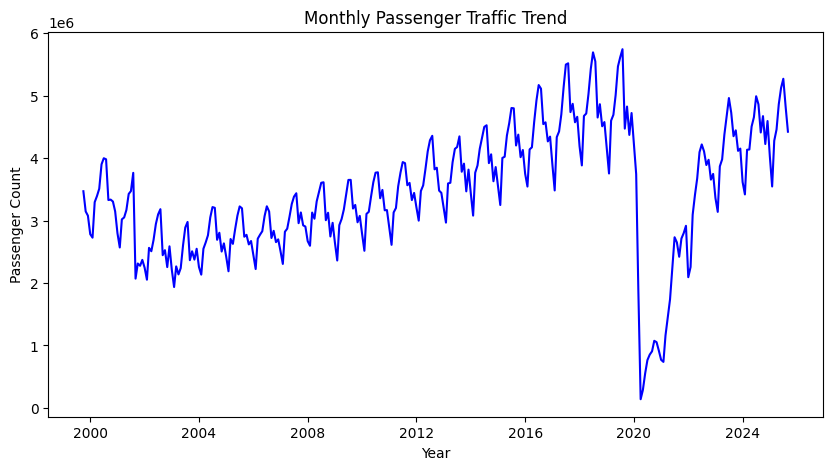

In [5]:
plt.figure(figsize=(10,5))
plt.plot(monthly_df['Activity Period'], monthly_df['Passenger Count'], color='blue')
plt.title("Monthly Passenger Traffic Trend")
plt.xlabel("Year")
plt.ylabel("Passenger Count")
plt.show()


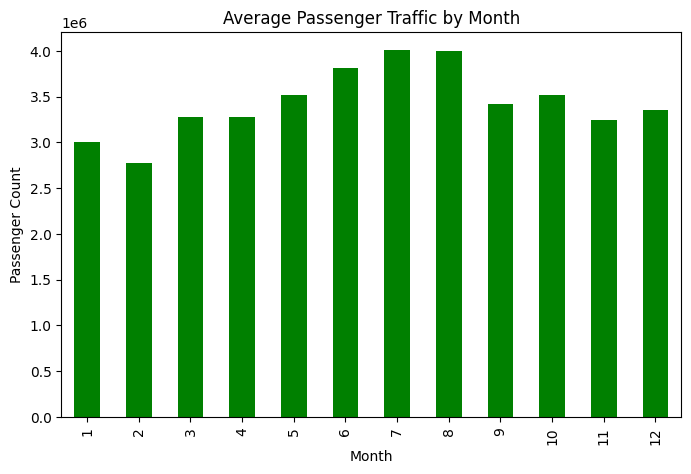

In [7]:
monthly_df.groupby('Month')['Passenger Count'].mean().plot(
    kind='bar', figsize=(8,5), color='green'
)
plt.title("Average Passenger Traffic by Month")
plt.xlabel("Month")
plt.ylabel("Passenger Count")
plt.show()


<h2 style="color:#20C997;">4. Regression Model Development</h2>


In [8]:
X = monthly_df[['Time_Index', 'Month', 'Lag_1', 'Lag_3']]
y = monthly_df['Passenger Count']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)


In [23]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("🔹 Linear Regression Performance")
print(f"MAE  : {mae_lr:,.2f}")
print(f"RMSE : {rmse_lr:,.2f}")
print(f"R²   : {r2_lr:.4f}")



🔹 Linear Regression Performance
MAE  : 367,673.24
RMSE : 446,903.15
R²   : 0.8856


In [24]:
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("🌲 Random Forest Regression Performance")
print(f"MAE  : {mae_rf:,.2f}")
print(f"RMSE : {rmse_rf:,.2f}")
print(f"R²   : {r2_rf:.4f}")




🌲 Random Forest Regression Performance
MAE  : 444,789.13
RMSE : 579,761.47
R²   : 0.8075


In [27]:
gbr = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gbr.fit(X_train, y_train)

# Predictions
y_pred_gbr = gbr.predict(X_test)

# Evaluation
mae_gbr = mean_absolute_error(y_test, y_pred_gbr)
rmse_gbr = np.sqrt(mean_squared_error(y_test, y_pred_gbr))
r2_gbr = r2_score(y_test, y_pred_gbr)

print("🚀 Gradient Boosting Regression Performance")
print(f"MAE  : {mae_gbr:,.2f}")
print(f"RMSE : {rmse_gbr:,.2f}")
print(f"R²   : {r2_gbr:.4f}")

🚀 Gradient Boosting Regression Performance
MAE  : 1,224,690.74
RMSE : 1,295,010.14
R²   : 0.0395


In [29]:
pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "Gradient Boosting"],
    "MAE": [mae_lr, mae_rf, mae_gbr],
    "RMSE": [rmse_lr, rmse_rf, rmse_gbr],
    "R² Score": [r2_lr, r2_rf, r2_gbr]
})


,Model,MAE,RMSE,R² Score
0,Linear Regression,3.676732e+05,4.469032e+05,0.885608
1,Random Forest,4.447891e+05,5.797615e+05,0.807483
2,Gradient Boosting,1.224691e+06,1.295010e+06,0.039456


<h2 style="color:#6610F2;">5. Actual vs Predicted Analysis</h2>


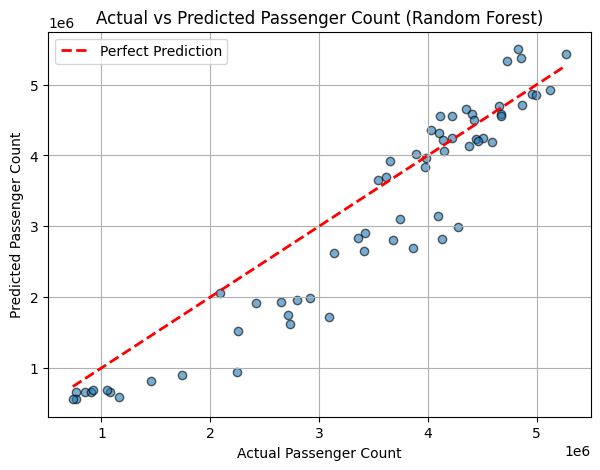

In [21]:
plt.figure(figsize=(7,5))

plt.scatter(
    y_test.values,
    y_pred_rf,
    alpha=0.6,
    edgecolors='black'
)

# Perfect prediction reference line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--',
    color='red',
    linewidth=2,
    label='Perfect Prediction'
)

plt.xlabel("Actual Passenger Count")
plt.ylabel("Predicted Passenger Count")
plt.title("Actual vs Predicted Passenger Count (Random Forest)")
plt.legend()
plt.grid(True)
plt.show()


<h2 style="color:#DC3545;">6. Classification: High vs Low Passenger Traffic</h2>


In [16]:
# Create binary class for model training
monthly_df['High_Traffic'] = (
    monthly_df['Passenger Count'] > monthly_df['Passenger Count'].median()
).astype(int)

# Create readable labels for interpretation
monthly_df['Traffic_Label'] = np.where(
    monthly_df['High_Traffic'] == 1,
    'High Traffic 🚀✈️',
    'Low Traffic 🟢🙂'
)

monthly_df[['Activity Period', 'Passenger Count', 'Traffic_Label']].head()


,Activity Period,Passenger Count,Traffic_Label
3,1999-10-01,3468846,High Traffic 🚀✈️
4,1999-11-01,3145240,Low Traffic 🟢🙂
5,1999-12-01,3077142,Low Traffic 🟢🙂
6,2000-01-01,2781129,Low Traffic 🟢🙂
7,2000-02-01,2725393,Low Traffic 🟢🙂


In [17]:
X_cls = monthly_df[['Month', 'Lag_1', 'Lag_3']]
y_cls = monthly_df['High_Traffic']

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_cls, y_cls, test_size=0.2, shuffle=False
)


In [18]:
clf = LogisticRegression(max_iter=1000)
clf.fit(Xc_train, yc_train)

yc_pred = clf.predict(Xc_test)

accuracy_score(yc_test, yc_pred)


0.6825396825396826

In [19]:
pd.DataFrame({
    "Actual Traffic": np.where(yc_test.values == 1, "High Traffic 🚀✈️", "Low Traffic 🟢🙂"),
    "Predicted Traffic": np.where(yc_pred == 1, "High Traffic 🚀✈️", "Low Traffic 🟢🙂")
}).head(10)


,Actual Traffic,Predicted Traffic
0,Low Traffic 🟢🙂,Low Traffic 🟢🙂
1,Low Traffic 🟢🙂,Low Traffic 🟢🙂
2,Low Traffic 🟢🙂,Low Traffic 🟢🙂
3,Low Traffic 🟢🙂,Low Traffic 🟢🙂
4,Low Traffic 🟢🙂,Low Traffic 🟢🙂
5,Low Traffic 🟢🙂,Low Traffic 🟢🙂
6,Low Traffic 🟢🙂,High Traffic 🚀✈️
7,Low Traffic 🟢🙂,Low Traffic 🟢🙂
8,Low Traffic 🟢🙂,Low Traffic 🟢🙂
9,Low Traffic 🟢🙂,High Traffic 🚀✈️


<h2 style="color:#00E5FF; text-align:center;">
🔮 User-Based Traffic Prediction (High vs Low)
</h2>

<p style="text-align:center; font-size:14px; color:lightgray;">
Enter custom passenger values to predict traffic category
</p>


In [31]:


# Example: user gives random values
user_month = 12        # December
user_lag1 = 5200000    # Last month passengers
user_lag3 = 2800000    # Passengers 3 months ago

# Create input in model format
user_input = pd.DataFrame([[user_month, user_lag1, user_lag3]],
                          columns=['Month', 'Lag_1', 'Lag_3'])

# Predict
user_prediction = clf.predict(user_input)[0]

# Convert prediction to readable label
result = "High Traffic 🚀✈️" if user_prediction == 1 else "Low Traffic 🟢🙂"

print("📊 Prediction Result:")
print(f"➡️ Traffic Category: {result}")


📊 Prediction Result:
➡️ Traffic Category: High Traffic 🚀✈️


<h2 style="color:#00E5FF;">7. Conclusion</h2>

<p>
This project successfully applied predictive analytics techniques on a real government air traffic dataset.
Three regression models — Linear Regression, Random Forest Regression, and Gradient Boosting Regression —
were trained to forecast monthly passenger counts. Among these, Random Forest Regression demonstrated
the best performance based on MAE, RMSE, and R² score.
</p>

<p>
In addition to regression, a classification model was developed to categorize passenger traffic into
<b>High Traffic</b> and <b>Low Traffic</b> periods. The classification results were presented in an
easy-to-understand format using meaningful labels and icons.
</p>

<p>
A key enhancement of this project is the <b>user-input based prediction feature</b>, where a user can
provide custom input values (month and recent passenger history), and the trained model predicts the
traffic category in real time. This makes the project interactive, practical, and closer to a real-world
decision-support system.
</p>


<h2 style="color:#00E5FF;">8. Future Scope</h2>

<ul>
  <li>Extend the user-input prediction module into a full web-based interface using Flask or Streamlit</li>
  <li>Incorporate additional external factors such as holidays, fuel prices, and economic indicators</li>
  <li>Apply advanced time-series models like ARIMA, SARIMA, or LSTM for long-term forecasting</li>
  <li>Perform airline-wise or route-wise passenger traffic prediction</li>
  <li>Deploy the trained model as a real-time forecasting API for airport or airline planning systems</li>
</ul>
